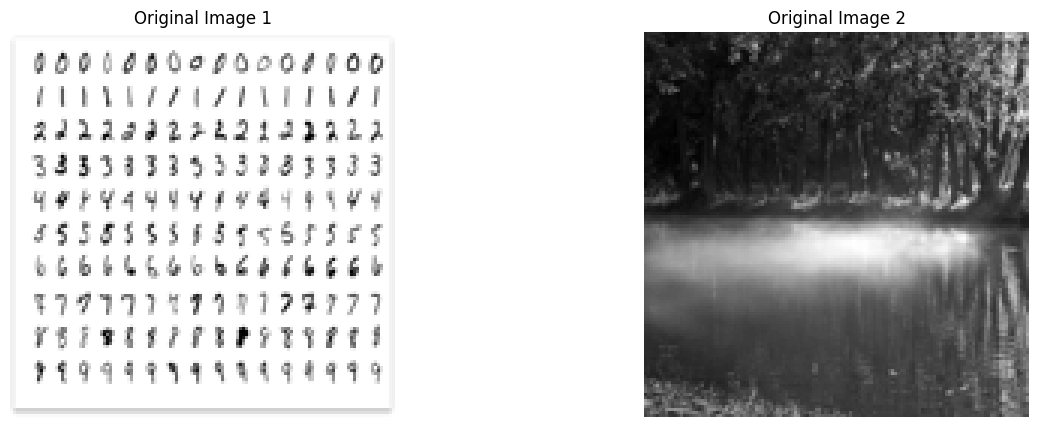


Original Images Histograms:


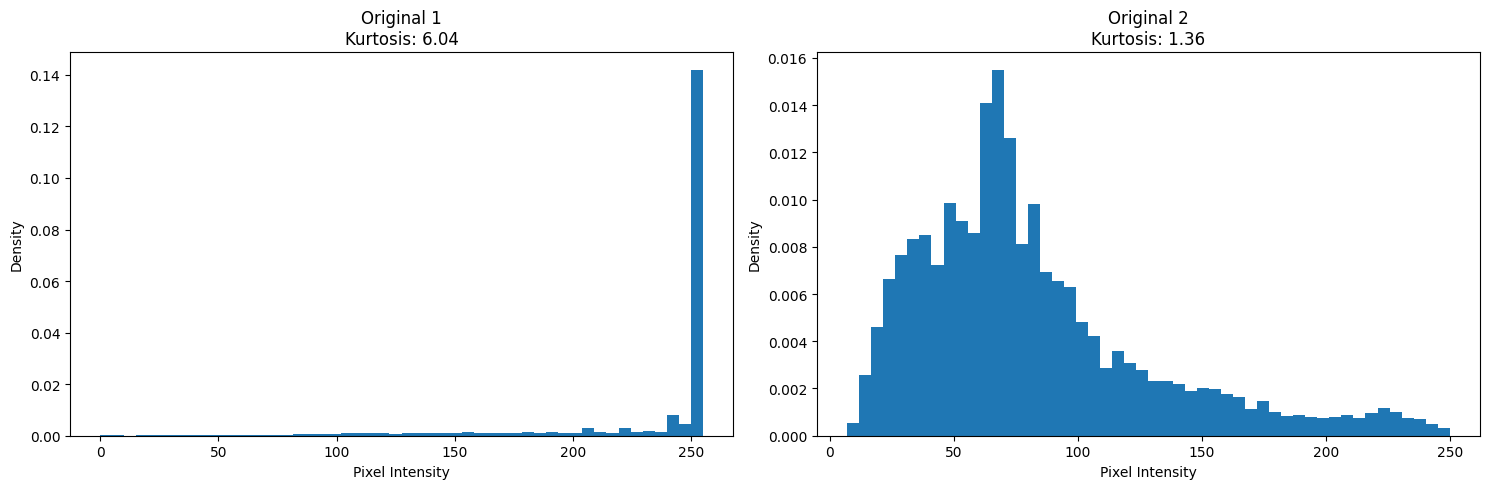

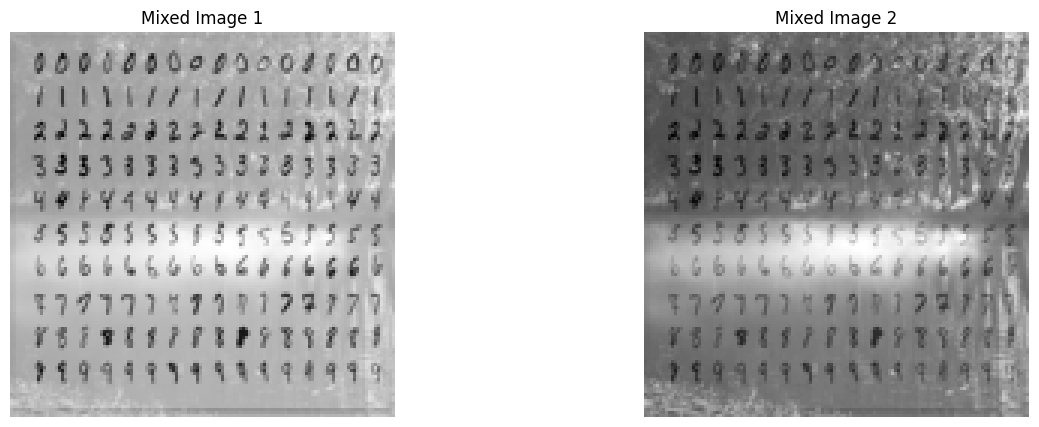


Mixed Images Histograms:


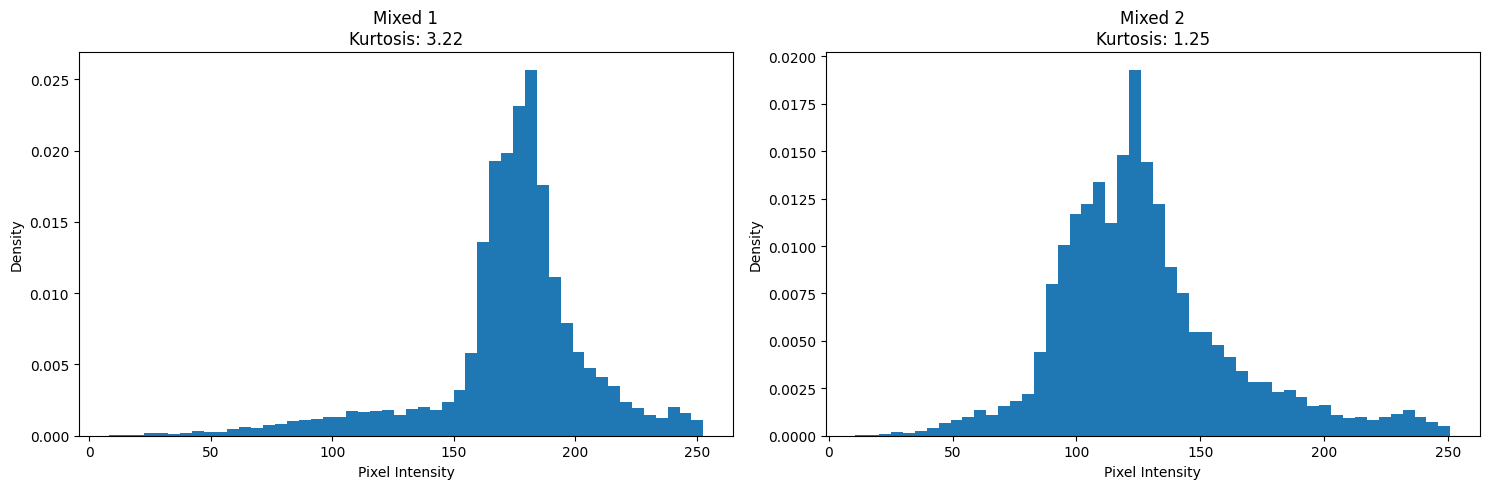

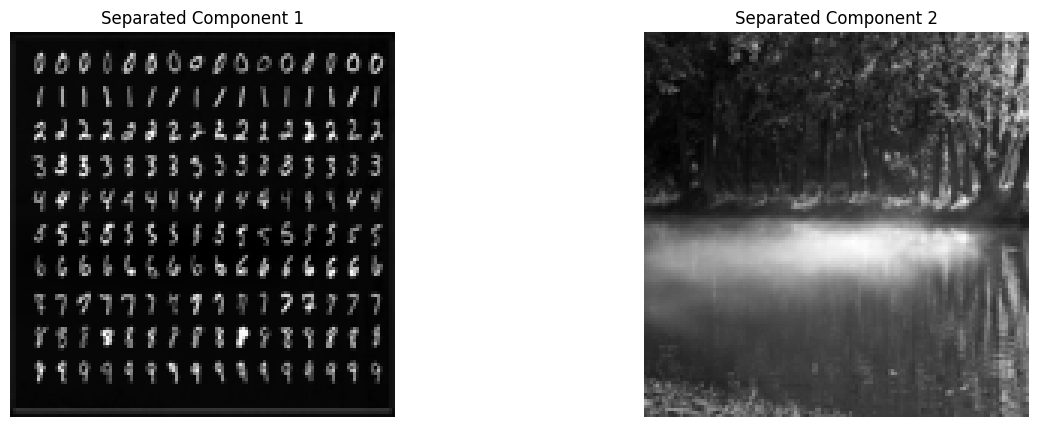


Separated Components Histograms:


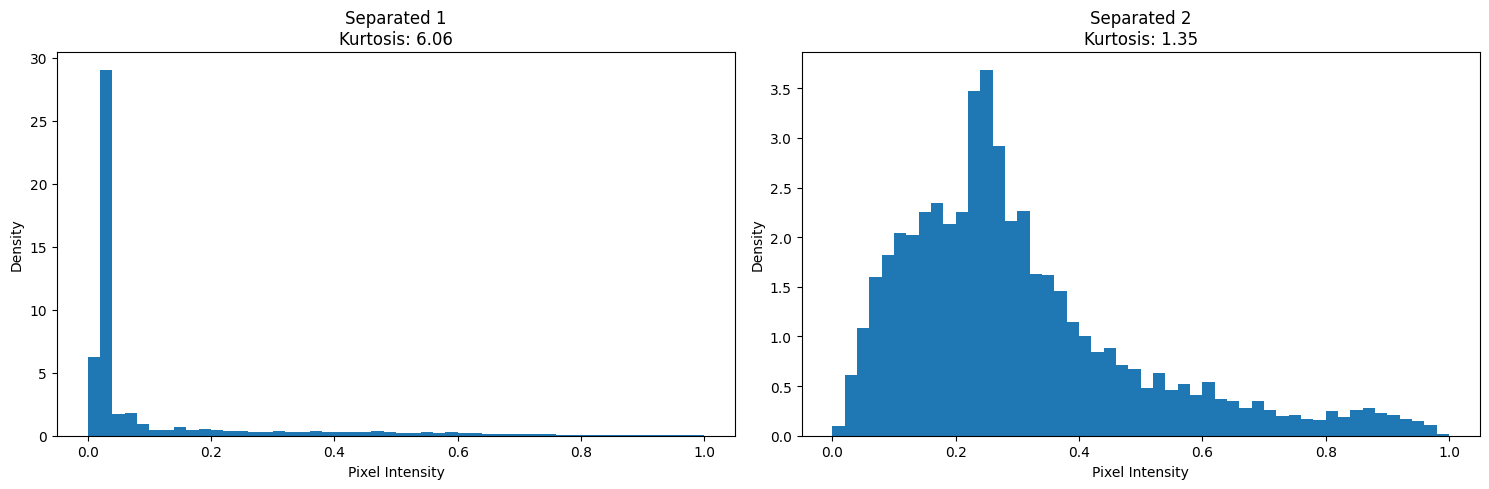

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

def load_and_preprocess_images(image_paths, size=(128, 128)):
    images = []
    for path in image_paths:
        img = Image.open(path).convert('L').resize(size)
        images.append(np.array(img, dtype=np.float64))  # Ensure float for mixing
    return images

def create_mixtures(images):
    mixed1 = 0.6*images[0] + 0.4*images[1]
    mixed2 = 0.3*images[0] + 0.7*images[1]
    return np.array([mixed1, mixed2])

def center_data(X):
    return X - np.mean(X, axis=1, keepdims=True)

def whiten_data(X):
    cov = np.cov(X)
    d, E = np.linalg.eigh(cov)
    D = np.diag(1. / np.sqrt(d + 1e-5))
    W = E @ D @ E.T
    return W @ X

def custom_fastica(X, max_iter=1000, tol=1e-4):
    n, p = X.shape
    W = np.random.randn(n, n)

    for _ in range(max_iter):
        wx = W @ X
        g = np.tanh(wx)
        g_prime = 1 - g**2
        W_new = (X @ g.T) / p - np.diag(g_prime.mean(axis=1)) @ W
        W_new, _ = np.linalg.qr(W_new)
        lim = max(abs(abs(np.diag(W_new @ W.T)) - 1))
        if lim < tol:
            break
        W = W_new
    return W

def plot_histograms(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.hist(img.flatten(), bins=50, density=True)
        plt.title(f"{title}\nKurtosis: {kurtosis(img.flatten(), fisher=True):.2f}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    image_paths = ['/content/digit.png', '/content/scenery.png']
    originals = load_and_preprocess_images(image_paths, size=(128, 128))

    plt.figure(figsize=(15, 5))
    for i, img in enumerate(originals):
        plt.subplot(1, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Original Image {i+1}")
        plt.axis('off')
    plt.show()

    print("\nOriginal Images Histograms:")
    plot_histograms(originals, [f"Original {i+1}" for i in range(2)])

    mixtures = create_mixtures(originals)

    plt.figure(figsize=(15, 5))
    for i, img in enumerate(mixtures):
        plt.subplot(1, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Mixed Image {i+1}")
        plt.axis('off')
    plt.show()

    print("\nMixed Images Histograms:")
    plot_histograms(mixtures, [f"Mixed {i+1}" for i in range(2)])

    X = mixtures.reshape(mixtures.shape[0], -1)
    X_centered = center_data(X)
    X_white = whiten_data(X_centered)
    W = custom_fastica(X_white)
    separated = W @ X_white

    separated_images = []
    for i in range(separated.shape[0]):
        img = separated[i].reshape(mixtures.shape[1:])
        img = (img - img.min()) / (img.max() - img.min())
        separated_images.append(img)

    plt.figure(figsize=(15, 5))
    for i, img in enumerate(separated_images):
        plt.subplot(1, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Separated Component {i+1}")
        plt.axis('off')
    plt.show()

    print("\nSeparated Components Histograms:")
    plot_histograms(separated_images, [f"Separated {i+1}" for i in range(2)])
